# Three-state model for tICA: is it noise or isnt it?

In [1]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
from itertools import combinations

# ---------------------------
import matplotlib.pyplot as plt
import matplotlib as mpl


mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM


Load data

In [2]:
trajectories_labels = ["tica_distances", "tica_dihedrals"]



total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003


Fit previously validated MSM

In [3]:
MSM_LAG_NS = 200
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos) # 200 ns
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 30
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")



msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj



for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
    dtraj = data["traj"].copy()
    #centers = data["centers"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(directed=True)
    print(f"Submodel for {name} has {submodel.n_states} microstates.")
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    #np.save(f"../intermediate_outputs/microstate_trajs/{N_CLUSTERS}clusters_{MSM_LAG_NS}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 10000)
    if np.any(dtrajs_dict[name] == -1):
        print(f"Warning: {name} has unassigned microstates after cleaning.")
    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

MSM lag time in frames: 1000
Submodel for tica_distances has 30 microstates.
Submodel for tica_dihedrals has 30 microstates.


## Three - state PCCA 

In [4]:
n_common = 3

pcca_dict = {}
pcca_memberships_dict = {}
macro_assignments_micro_dict = {}

for name in trajectories_labels:
    msm = msm_dict[name]

    pcca = msm.pcca(n_common)
    pcca_dict[name] = pcca

    # shape: n_microstates x 3
    memberships = pcca.memberships
    pcca_memberships_dict[name] = memberships

    # hard assignment of each microstate
    macro_assignments_micro = memberships.argmax(axis=1)
    macro_assignments_micro_dict[name] = macro_assignments_micro

Project onto the timeseries (soft and hard)

In [5]:
pcca_probabilities_timeseries_dict = {}

hard_assignments_timeseries_dict = {}

for name in trajectories_labels:
    dtraj = dtrajs_dict[name]
    memberships = pcca_memberships_dict[name]
    pcca_probabilities_timeseries_dict[name] = memberships[dtraj, :]

    # probability of belonging to macrostate 1
    p_macro1 = memberships[dtraj, 1]
    p_macro2 = memberships[dtraj, 2]

    # hard macrostate assignment
    hard = np.argmax(memberships[dtraj, :], axis=1)


    #p1_timeseries_dict[name] = p_macro1
    #p2_timeseries_dict[name] = p_macro2
    hard_assignments_timeseries_dict[name] = hard

Compare assignment probabilities

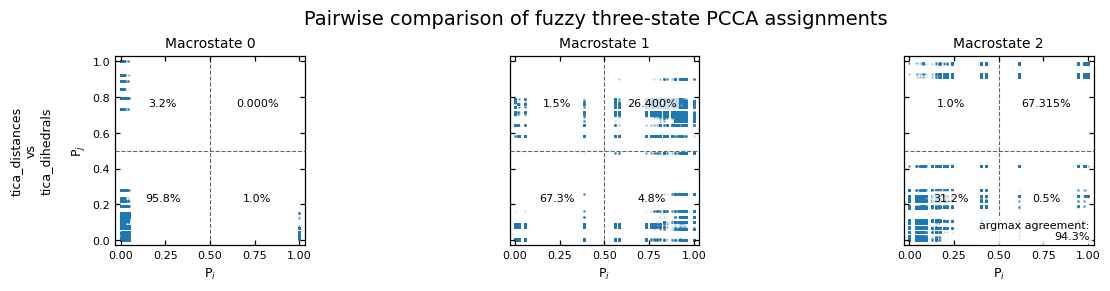

In [6]:
def ensure_membership_matrix(p):
    """
    Ensure PCCA probabilities have shape (n_frames, n_macrostates).
    """
    p = np.asarray(p)

    if p.ndim != 2:
        raise ValueError(
            f"Expected a 2D array of shape (n_frames, n_macrostates), got shape {p.shape}"
        )

    # If stored as (n_macrostates, n_frames), transpose it.
    if p.shape[0] == 3 and p.shape[1] != 3:
        p = p.T

    return p


def quadrant_fractions(pi, pj, threshold=0.5):
    """
    Fractions of frames in the four regions defined by a threshold.

    x-axis: membership probability from model i
    y-axis: membership probability from model j
    """

    q00 = np.mean((pi < threshold) & (pj < threshold))
    q10 = np.mean((pi >= threshold) & (pj < threshold))
    q01 = np.mean((pi < threshold) & (pj >= threshold))
    q11 = np.mean((pi >= threshold) & (pj >= threshold))

    return {
        "q00": q00,
        "q10": q10,
        "q01": q01,
        "q11": q11,
    }


def add_quadrant_annotations(ax, quad, fontsize=8):
    """
    Add quadrant percentages in axes coordinates.
    """

    bbox = dict(
        boxstyle="round,pad=0.2",
        facecolor="white",
        alpha=0.75,
        edgecolor="none"
    )

    ax.text(
        0.25, 0.25,
        f"{100 * quad['q00']:.1f}%",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize,
        bbox=bbox
    )

    ax.text(
        0.75, 0.25,
        f"{100 * quad['q10']:.1f}%",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize,
        bbox=bbox
    )

    ax.text(
        0.25, 0.75,
        f"{100 * quad['q01']:.1f}%",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize,
        bbox=bbox
    )

    ax.text(
        0.75, 0.75,
        f"{100 * quad['q11']:.3f}%",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize,
        bbox=bbox
    )


# ----------------------------------------------------
# Pairwise fuzzy PCCA membership comparison, 3 states
# ----------------------------------------------------

n_macrostates = 3
threshold = 0.5

pairs = list(combinations(trajectories_labels, 2))
n_pairs = len(pairs)

fig, axs = plt.subplots(
    nrows=n_pairs,
    ncols=n_macrostates,
    figsize=(4.0 * n_macrostates, 2.8 * n_pairs),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# Make axs always 2D
axs = np.asarray(axs)
if axs.ndim == 1:
    axs = axs.reshape(n_pairs, n_macrostates)


for row, (name_i, name_j) in enumerate(pairs):

    Pi = ensure_membership_matrix(pcca_probabilities_timeseries_dict[name_i]) 
    Pj = ensure_membership_matrix(pcca_probabilities_timeseries_dict[name_j])

    if Pi.shape != Pj.shape:
        raise ValueError(
            f"Shape mismatch for {name_i} and {name_j}: {Pi.shape} vs {Pj.shape}"
        )

    if Pi.shape[1] != n_macrostates:
        raise ValueError(
            f"Expected {n_macrostates} macrostates, got {Pi.shape[1]} for {name_i}"
        )

    # Hard assignments, useful as a compact agreement diagnostic
    hard_i = np.argmax(Pi, axis=1)
    hard_j = np.argmax(Pj, axis=1)
    hard_agreement = np.mean(hard_i == hard_j)

    for k in range(n_macrostates):

        ax = axs[row, k]

        pi = Pi[:, k]
        pj = Pj[:, k]

        quad = quadrant_fractions(pi, pj, threshold=threshold)

        ax.scatter(
            pi,
            pj,
            s=0.7,
            alpha=0.03,
            rasterized=True
        )

        ax.axhline(
            threshold,
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.6
        )

        ax.axvline(
            threshold,
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.6
        )

        add_quadrant_annotations(ax, quad, fontsize=8)

        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(-0.03, 1.03)
        ax.set_aspect("equal")

        if row == 0:
            ax.set_title(f"Macrostate {k}", fontsize=10)

        if k == 0:
            ax.set_ylabel(
                f"{name_i}\nvs\n{name_j}\n\nP$_j$",
                fontsize=9
            )

        if row == n_pairs - 1:
            ax.set_xlabel("P$_i$", fontsize=9)

        ax.tick_params(axis="both", labelsize=8)

    # Add pairwise hard-assignment agreement on the last panel of the row
    axs[row, -1].text(
        0.98,
        0.02,
        f"argmax agreement:\n{100 * hard_agreement:.1f}%",
        transform=axs[row, -1].transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            alpha=0.85,
            edgecolor="none"
        )
    )


fig.suptitle(
    "Pairwise comparison of fuzzy three-state PCCA assignments",
    fontsize=14
)

#plt.savefig(
##    "../output_figures/pairwise_pcca_membership_scatter_3state_report.pdf",
#    bbox_inches="tight"
#)

#plt.savefig(
#    "../output_figures/pairwise_pcca_membership_scatter_3state_report.png",
#    dpi=600,
#    bbox_inches="tight"
#)

plt.show()

In [7]:
# populations

distribution_dict = {}
for label in trajectories_labels:
    pcca_model = pcca_dict[label]
    distribution = pcca_model.coarse_grained_stationary_probability
    distribution_dict[label] = distribution
    print(f"{label}: {distribution}") 

tica_distances: [0.01740067 0.25594054 0.72665879]
tica_dihedrals: [0.04684419 0.23358832 0.71956748]


- clearly, macrostate 3 is folded and macrostate 2 is unfolded.
- Macrostate 0 has very little population and no overlap, so it is difficult to say if it represents something physical.

---

### Structural caracterization

Seems like this metastable state describes a relaxation within the unfolded basin. So the next question is structural caracterization: can we find something that caracterizes it as distinct with respect to basin 1 - unfolded?

In [8]:
stride = 1000


distances_macro0_frames = np.where(hard_assignments_timeseries_dict["tica_distances"] == 0)[0][::stride]
print("Number of frames assigned to macrostate 0 in tica_distances:", len(distances_macro0_frames))
filepath = "../intermediate_outputs/frame_lists/"
os.makedirs(filepath, exist_ok=True)

filename = os.path.join(filepath, "tica_distances_macro0_frames.npy")
np.save(filename, distances_macro0_frames)

Number of frames assigned to macrostate 0 in tica_distances: 16


In [9]:
stride = 4000
dihedrals_macro0_frames = np.where(hard_assignments_timeseries_dict["tica_dihedrals"] == 0)[0][::stride]
print("Number of frames assigned to macrostate 0 in tica_dihedrals:", len(dihedrals_macro0_frames))
filepath = "../intermediate_outputs/frame_lists/"
os.makedirs(filepath, exist_ok=True)

filename = os.path.join(filepath, "tica_dihedrals_macro0_frames.npy")
np.save(filename, dihedrals_macro0_frames)

Number of frames assigned to macrostate 0 in tica_dihedrals: 13


**Results**

The dominant folded/unfolded separation is robust, and both models indicate internal heterogeneity of the unfolded basin. However, the additional macrostate identified at three-state resolution is not conserved across feature spaces. The distance-based MSM isolates a partially folded, native-like subensemble with helices 2 and 3 formed and helix 1 disrupted, whereas the dihedral-based MSM isolates a distinct low-helicity hairpin-like subensemble. Since the overlap between these two macrostates is negligible, they should be interpreted as different unfolded-basin substates rather than as alternative descriptions of the same state.

---

# Network analysis

In [34]:
def compute_equilibrium_traffic(T, pi):
    """
    Compute symmetrized equilibrium transition traffic.

    traffic_ij = pi_i T_ij + pi_j T_ji

    Diagonal entries are set to zero.
    """
    T = np.asarray(T, dtype=float)
    pi = np.asarray(pi, dtype=float)
    pi = pi / pi.sum()

    flux = pi[:, None] * T
    traffic = flux + flux.T
    np.fill_diagonal(traffic, 0.0)

    return traffic


def plot_microstate_equilibrium_traffic(
    msm,
    macro_assignments_micro=None,
    ax=None,
    labels=None,
    state_colors=None,
    min_traffic_quantile=0.90,
    top_k_edges=None,
    node_size_range=(10, 1200),
    edge_width_range=(0.4, 5.0),
    layout="spring",
    seed=0,
):
    """
    Plot the microstate MSM as an equilibrium traffic network.

    Nodes:
        microstates

    Node size:
        stationary population pi_i

    Node color:
        PCCA macrostate assignment, if provided

    Edges:
        undirected equilibrium traffic:
        traffic_ij = pi_i T_ij + pi_j T_ji

    Parameters
    ----------
    msm
        Deeptime MSM object.
    macro_assignments_micro
        Array of shape (n_microstates,), giving hard PCCA macrostate assignment
        for each microstate.
    min_traffic_quantile
        Keeps only edges whose traffic is above this quantile among nonzero
        traffic values. Use None to disable quantile filtering.
    top_k_edges
        If not None, keep only the globally strongest top_k_edges.
    layout
        "spring" or "spectral".
    """

    T = np.asarray(msm.transition_matrix, dtype=float)
    pi = np.asarray(msm.stationary_distribution, dtype=float)
    pi = pi / pi.sum()

    n = T.shape[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))

    if labels is None:
        labels = {i: str(i) for i in range(n)}
    else:
        labels = {i: str(labels[i]) for i in range(n)}

    # -----------------------------
    # Compute equilibrium traffic
    # -----------------------------
    traffic = compute_equilibrium_traffic(T, pi)

    nonzero_traffic = traffic[traffic > 0]

    if len(nonzero_traffic) == 0:
        raise ValueError("No nonzero off-diagonal traffic found.")

    if min_traffic_quantile is not None:
        min_traffic = np.quantile(nonzero_traffic, min_traffic_quantile)
    else:
        min_traffic = 0.0

    # -----------------------------
    # Build full graph for layout
    # -----------------------------
    G_full = nx.Graph()
    G_full.add_nodes_from(range(n))

    for i in range(n):
        for j in range(i + 1, n):
            if traffic[i, j] > 0:
                G_full.add_edge(i, j, weight=traffic[i, j])

    # -----------------------------
    # Layout
    # -----------------------------
    if layout == "spring":
        pos = nx.spring_layout(
            G_full,
            weight="weight",
            seed=seed,
            k=1.5 / np.sqrt(n)
        )

    elif layout == "spectral":
        pos = nx.spectral_layout(
            G_full,
            weight="weight"
        )

    else:
        raise ValueError("layout must be either 'spring' or 'spectral'.")

    # -----------------------------
    # Select edges to plot
    # -----------------------------
    edge_candidates = []

    for i in range(n):
        for j in range(i + 1, n):
            if traffic[i, j] >= min_traffic:
                edge_candidates.append((i, j, traffic[i, j]))

    edge_candidates = sorted(
        edge_candidates,
        key=lambda x: x[2],
        reverse=True
    )

    if top_k_edges is not None:
        edge_candidates = edge_candidates[:top_k_edges]

    G_plot = nx.Graph()
    G_plot.add_nodes_from(range(n))

    for i, j, weight in edge_candidates:
        G_plot.add_edge(i, j, weight=weight)

    # -----------------------------
    # Node sizes from stationary population
    # -----------------------------
    smin, smax = node_size_range

    if pi.max() > pi.min():
        node_sizes = smin + (pi - pi.min()) / (pi.max() - pi.min()) * (smax - smin)
    else:
        node_sizes = np.full(n, 0.5 * (smin + smax))

    # -----------------------------
    # Node colors
    # -----------------------------
    if state_colors is not None:
        node_colors = state_colors

    elif macro_assignments_micro is not None:
        macro_assignments_micro = np.asarray(macro_assignments_micro)
        cmap = plt.get_cmap("tab10")
        node_colors = [cmap(int(macro_assignments_micro[i]) % 10) for i in range(n)]

    else:
        node_colors = ["lightgrey"] * n

    # -----------------------------
    # Edge widths
    # -----------------------------
    edges = list(G_plot.edges())
    weights = np.array([G_plot[u][v]["weight"] for u, v in edges])

    if len(weights) > 0 and weights.max() > weights.min():
        wmin, wmax = edge_width_range
        edge_widths = wmin + (weights - weights.min()) / (weights.max() - weights.min()) * (wmax - wmin)
    elif len(weights) > 0:
        edge_widths = np.full(len(weights), np.mean(edge_width_range))
    else:
        edge_widths = []

    # -----------------------------
    # Draw
    # -----------------------------
    nx.draw_networkx_edges(
        G_plot,
        pos,
        ax=ax,
        edgelist=edges,
        width=edge_widths,
        arrows=False,
        alpha=0.55
    )

    nx.draw_networkx_nodes(
        G_plot,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors="black",
        linewidths=0.8,
        alpha=0.85
    )

    nx.draw_networkx_labels(
        G_plot,
        pos,
        labels=labels,
        ax=ax,
        font_size=7,
        font_weight="bold"
    )

    ax.set_title("Microstate equilibrium transition traffic")
    ax.axis("off")

    return ax, G_plot, pos, traffic

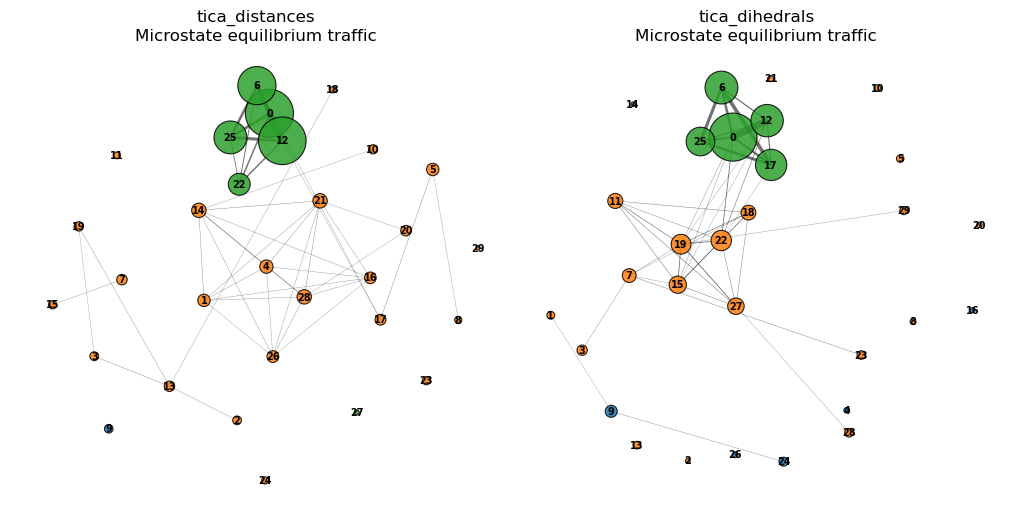

In [38]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(trajectories_labels),
    figsize=(5 * len(trajectories_labels), 5),
    constrained_layout=True
)

if len(trajectories_labels) == 1:
    axs = [axs]

traffic_dict = {}
traffic_graph_dict = {}
traffic_pos_dict = {}

for ax, name in zip(axs, trajectories_labels):
    msm = msm_dict[name]
    macro_assignments_micro = macro_assignments_micro_dict[name]

    ax, G_plot, pos, traffic = plot_microstate_equilibrium_traffic(
        msm=msm,
        macro_assignments_micro=macro_assignments_micro,
        ax=ax,
        min_traffic_quantile=0.90,   # increase to 0.85 or 0.90 for cleaner plot
        top_k_edges=None,            # or e.g. 40
        node_size_range=(10, 1200),
        edge_width_range=(0.2, 5.0),
        layout="spring",
        seed=1
    )

    ax.set_title(f"{name}\nMicrostate equilibrium traffic")

    traffic_dict[name] = traffic
    traffic_graph_dict[name] = G_plot
    traffic_pos_dict[name] = pos

plt.show()

In [12]:
bridge_score_dict = {}

for name in trajectories_labels:
    traffic = traffic_dict[name]
    macro = macro_assignments_micro_dict[name]
    pi = msm_dict[name].stationary_distribution

    n = traffic.shape[0]
    external_fraction = np.zeros(n)
    total_traffic = traffic.sum(axis=1)
    external_traffic = np.zeros(n)

    for i in range(n):
        other_macro = macro != macro[i]
        external_traffic[i] = traffic[i, other_macro].sum()

        if total_traffic[i] > 0:
            external_fraction[i] = external_traffic[i] / total_traffic[i]
        else:
            external_fraction[i] = 0.0

    bridge_df = pd.DataFrame({
        "microstate": np.arange(n),
        "macrostate": macro,
        "pi": pi,
        "total_traffic": total_traffic,
        "external_traffic": external_traffic,
        "external_fraction": external_fraction,
    })

    bridge_df = bridge_df.sort_values(
        ["external_fraction", "external_traffic"],
        ascending=False
    )

    bridge_score_dict[name] = bridge_df

    print("\n", name)
    display(bridge_df.head(10))


 tica_distances


,microstate,macrostate,pi,total_traffic,external_traffic,external_fraction
9,9,0,0.010228,0.004595,0.004595,1.000000
27,27,2,0.006005,0.011407,0.004849,0.425065
17,17,1,0.014053,0.026062,0.008066,0.309486
8,8,1,0.008327,0.013996,0.003965,0.283297
5,5,1,0.017123,0.022242,0.006085,0.273589
28,28,1,0.021791,0.039481,0.006107,0.154678
21,21,1,0.021853,0.039129,0.005154,0.131726
23,23,1,0.009606,0.018616,0.001961,0.105329
4,4,1,0.019274,0.035374,0.003607,0.101978
26,26,1,0.015899,0.029019,0.002947,0.101569



 tica_dihedrals


,microstate,macrostate,pi,total_traffic,external_traffic,external_fraction
9,9,0,0.015077,0.016714,0.009436,0.564537
4,4,0,0.002478,0.004324,0.002064,0.477186
1,1,1,0.005804,0.011142,0.004351,0.390543
22,22,1,0.044972,0.060918,0.022698,0.372601
24,24,0,0.008016,0.010988,0.003856,0.350924
26,26,0,0.002778,0.004930,0.001538,0.312037
16,16,0,0.001820,0.003398,0.000760,0.223537
10,10,1,0.004035,0.007561,0.001633,0.216002
20,20,1,0.002345,0.004652,0.000755,0.162387
8,8,1,0.002831,0.005617,0.000867,0.154365


In [13]:


def get_ordered_transition_matrix(
    msm,
    macro_assignments_micro,
    sort_within_macro="population",
):
    """
    Reorder a microstate transition matrix by PCCA macrostate.

    Parameters
    ----------
    msm
        Deeptime MSM object.
    macro_assignments_micro : array-like, shape (n_microstates,)
        Hard PCCA macrostate assignment for each microstate.
    sort_within_macro : str
        How to order microstates inside each macrostate.

        Options:
        - "population": sort by decreasing stationary population
        - "index": sort by original microstate index
        - "none": same as "index"

    Returns
    -------
    T_ordered : ndarray
        Reordered transition matrix.
    order : ndarray
        Microstate indices in the new order.
    macro_ordered : ndarray
        Macrostate labels in the new order.
    pi_ordered : ndarray
        Stationary probabilities in the new order.
    boundaries : list
        Positions where macrostate blocks end.
    """

    T = np.asarray(msm.transition_matrix, dtype=float)
    pi = np.asarray(msm.stationary_distribution, dtype=float)
    macro = np.asarray(macro_assignments_micro)

    n = T.shape[0]

    if len(macro) != n:
        raise ValueError(
            f"macro_assignments_micro has length {len(macro)}, but MSM has {n} states."
        )

    unique_macros = np.unique(macro)

    order = []

    for m in unique_macros:
        idx = np.where(macro == m)[0]

        if sort_within_macro == "population":
            idx = idx[np.argsort(pi[idx])[::-1]]

        elif sort_within_macro in ["index", "none"]:
            idx = np.sort(idx)

        else:
            raise ValueError("sort_within_macro must be 'population', 'index', or 'none'.")

        order.extend(idx)

    order = np.array(order, dtype=int)

    T_ordered = T[order][:, order]
    macro_ordered = macro[order]
    pi_ordered = pi[order]

    boundaries = []
    current = 0

    for m in unique_macros:
        current += np.sum(macro == m)
        boundaries.append(current)

    return T_ordered, order, macro_ordered, pi_ordered, boundaries

In [14]:
def plot_ordered_transition_matrix(
    msm,
    macro_assignments_micro,
    ax=None,
    sort_within_macro="population",
    cmap="Reds",
    log_scale=False,
    show_microstate_labels=True,
    show_colorbar=True,
    title=None,
):
    """
    Plot the microstate transition matrix ordered by PCCA macrostate.

    Diagonal block structure indicates metastable sets.
    Off-diagonal blocks indicate inter-macrostate transitions.
    """

    T_ordered, order, macro_ordered, pi_ordered, boundaries = get_ordered_transition_matrix(
        msm=msm,
        macro_assignments_micro=macro_assignments_micro,
        sort_within_macro=sort_within_macro,
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    if log_scale:
        # Useful if off-diagonal entries are much smaller than diagonal entries
        matrix_to_plot = np.log10(T_ordered + 1e-12)
        im = ax.imshow(matrix_to_plot, cmap=cmap, interpolation="nearest")
        cbar_label = r"$\log_{10}(T_{ij} + 10^{-12})$"
    else:
        matrix_to_plot = T_ordered
        im = ax.imshow(matrix_to_plot, cmap=cmap, interpolation="nearest", vmin=0)
        cbar_label = r"$T_{ij}$"

    # Draw block boundaries between PCCA macrostates
    for b in boundaries[:-1]:
        ax.axhline(b - 0.5, color="black", linewidth=1.2)
        ax.axvline(b - 0.5, color="black", linewidth=1.2)

    # Tick labels: original microstate indices after reordering
    n = T_ordered.shape[0]

    if show_microstate_labels:
        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(n))
        ax.set_xticklabels(order, rotation=90, fontsize=6)
        ax.set_yticklabels(order, fontsize=6)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    ax.set_xlabel("To microstate")
    ax.set_ylabel("From microstate")

    if title is None:
        title = "Transition matrix ordered by PCCA macrostate"

    ax.set_title(title)

    if show_colorbar:
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(cbar_label)

    return ax, T_ordered, order, macro_ordered, pi_ordered, boundaries

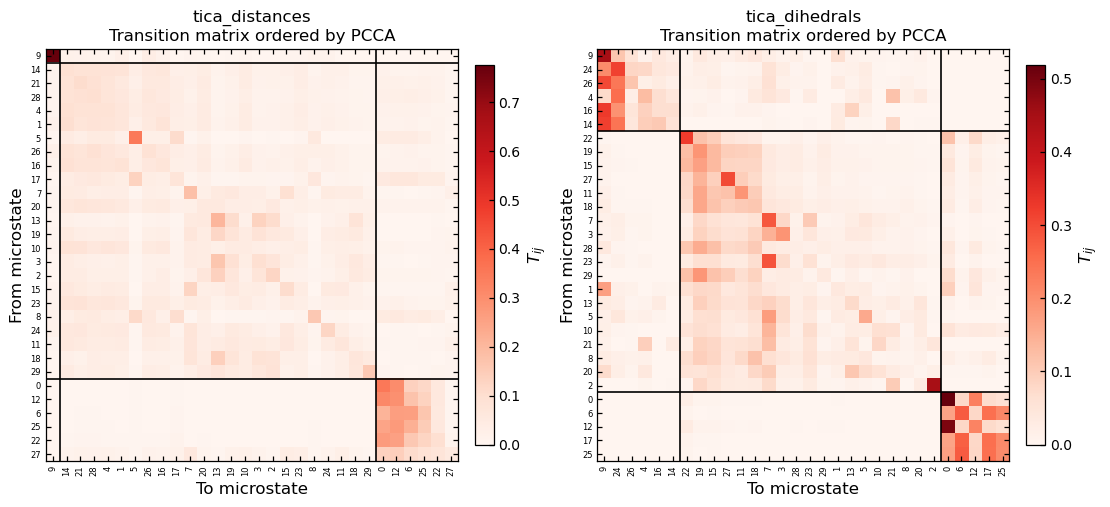

In [15]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(trajectories_labels),
    figsize=(5.5 * len(trajectories_labels), 5),
    constrained_layout=True
)

if len(trajectories_labels) == 1:
    axs = [axs]

ordered_T_dict = {}
microstate_order_dict = {}
macro_ordered_dict = {}
pi_ordered_dict = {}
boundaries_dict = {}

for ax, name in zip(axs, trajectories_labels):
    msm = msm_dict[name]
    macro_assignments_micro = macro_assignments_micro_dict[name]

    ax, T_ordered, order, macro_ordered, pi_ordered, boundaries = plot_ordered_transition_matrix(
        msm=msm,
        macro_assignments_micro=macro_assignments_micro,
        ax=ax,
        sort_within_macro="population",
        cmap="Reds",
        log_scale=False,
        show_microstate_labels=True,
        show_colorbar=True,
        title=f"{name}\nTransition matrix ordered by PCCA"
    )

    ordered_T_dict[name] = T_ordered
    microstate_order_dict[name] = order
    macro_ordered_dict[name] = macro_ordered
    pi_ordered_dict[name] = pi_ordered
    boundaries_dict[name] = boundaries

plt.show()

**tica distances**
- state 9 in tica_distances looks like a kinetic trap
- the unfolded basin does not contain metastable states, they all move 
- the folded basin contains states that interconvert between each other.

In [16]:
def compute_equilibrium_traffic(T, pi):
    """
    Compute symmetrized equilibrium transition traffic.

    traffic_ij = pi_i T_ij + pi_j T_ji

    Diagonal entries are set to zero.
    """
    T = np.asarray(T, dtype=float)
    pi = np.asarray(pi, dtype=float)
    pi = pi / pi.sum()

    flux = pi[:, None] * T
    traffic = flux + flux.T
    np.fill_diagonal(traffic, 0.0)

    return traffic

In [17]:
def get_dynamical_eigenvector_coordinates(
    msm,
    x_mode=1,
    y_mode=2,
    normalize=True,
):
    """
    Get microstate coordinates from right eigenvectors of the MSM.

    x_mode=1 means the first non-stationary mode.
    y_mode=2 means the second non-stationary mode.

    mode 0 is the stationary/trivial eigenvector and is usually skipped.

    Returns
    -------
    x : ndarray
        x coordinates for microstates.
    y : ndarray
        y coordinates for microstates.
    eigvals : ndarray
        Eigenvalues sorted by decreasing real part.
    eigvecs : ndarray
        Corresponding right eigenvectors.
    """

    T = np.asarray(msm.transition_matrix, dtype=float)

    eigvals, eigvecs = np.linalg.eig(T)

    # Sort by decreasing real part of eigenvalue
    order = np.argsort(np.real(eigvals))[::-1]
    eigvals = np.real(eigvals[order])
    eigvecs = np.real(eigvecs[:, order])

    x = eigvecs[:, x_mode]
    y = eigvecs[:, y_mode]

    # Fix arbitrary sign convention for reproducibility
    if np.sum(x) < 0:
        x = -x
    if np.sum(y) < 0:
        y = -y

    if normalize:
        if np.max(np.abs(x)) > 0:
            x = x / np.max(np.abs(x))
        if np.max(np.abs(y)) > 0:
            y = y / np.max(np.abs(y))

    return x, y, eigvals, eigvecs

In [18]:
def plot_microstate_traffic_dynamical_layout(
    msm,
    macro_assignments_micro=None,
    ax=None,
    labels=None,
    x_mode=1,
    y_mode=2,
    min_traffic_quantile=0.80,
    top_k_edges=None,
    node_size_range=(100, 1200),
    edge_width_range=(0.4, 5.0),
    show_labels=True,
    seed_jitter=0,
    jitter=0.0,
):
    """
    Plot microstate equilibrium traffic network using dynamical eigenvector coordinates.

    Node position:
        x_i = right eigenvector x_mode evaluated at microstate i
        y_i = right eigenvector y_mode evaluated at microstate i

    Node size:
        stationary probability pi_i

    Node color:
        hard PCCA macrostate assignment, if provided

    Edge width:
        symmetrized equilibrium traffic:
        traffic_ij = pi_i T_ij + pi_j T_ji
    """

    T = np.asarray(msm.transition_matrix, dtype=float)
    pi = np.asarray(msm.stationary_distribution, dtype=float)
    pi = pi / pi.sum()

    n = T.shape[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    if labels is None:
        labels = {i: str(i) for i in range(n)}
    else:
        labels = {i: str(labels[i]) for i in range(n)}

    # -----------------------------
    # Dynamical coordinates
    # -----------------------------
    x, y, eigvals, eigvecs = get_dynamical_eigenvector_coordinates(
        msm=msm,
        x_mode=x_mode,
        y_mode=y_mode,
        normalize=True,
    )

    if jitter > 0:
        rng = np.random.default_rng(seed_jitter)
        x = x + rng.normal(scale=jitter, size=n)
        y = y + rng.normal(scale=jitter, size=n)

    pos = {i: np.array([x[i], y[i]]) for i in range(n)}

    # -----------------------------
    # Equilibrium traffic
    # -----------------------------
    traffic = compute_equilibrium_traffic(T, pi)

    nonzero_traffic = traffic[traffic > 0]

    if len(nonzero_traffic) == 0:
        raise ValueError("No nonzero off-diagonal traffic found.")

    if min_traffic_quantile is not None:
        min_traffic = np.quantile(nonzero_traffic, min_traffic_quantile)
    else:
        min_traffic = 0.0

    # -----------------------------
    # Build graph
    # -----------------------------
    edge_candidates = []

    for i in range(n):
        for j in range(i + 1, n):
            if traffic[i, j] >= min_traffic:
                edge_candidates.append((i, j, traffic[i, j]))

    edge_candidates = sorted(
        edge_candidates,
        key=lambda x: x[2],
        reverse=True
    )

    if top_k_edges is not None:
        edge_candidates = edge_candidates[:top_k_edges]

    G_plot = nx.Graph()
    G_plot.add_nodes_from(range(n))

    for i, j, weight in edge_candidates:
        G_plot.add_edge(i, j, weight=weight)

    edges = list(G_plot.edges())
    weights = np.array([G_plot[u][v]["weight"] for u, v in edges])

    # -----------------------------
    # Node sizes
    # -----------------------------
    smin, smax = node_size_range

    if pi.max() > pi.min():
        node_sizes = smin + (pi - pi.min()) / (pi.max() - pi.min()) * (smax - smin)
    else:
        node_sizes = np.full(n, 0.5 * (smin + smax))

    # -----------------------------
    # Node colors
    # -----------------------------
    if macro_assignments_micro is not None:
        macro_assignments_micro = np.asarray(macro_assignments_micro)
        cmap = plt.get_cmap("tab10")
        node_colors = [
            cmap(int(macro_assignments_micro[i]) % 10)
            for i in range(n)
        ]
    else:
        node_colors = ["lightgrey"] * n

    # -----------------------------
    # Edge widths
    # -----------------------------
    if len(weights) > 0 and weights.max() > weights.min():
        wmin, wmax = edge_width_range
        edge_widths = wmin + (weights - weights.min()) / (weights.max() - weights.min()) * (wmax - wmin)
    elif len(weights) > 0:
        edge_widths = np.full(len(weights), np.mean(edge_width_range))
    else:
        edge_widths = []

    # -----------------------------
    # Draw
    # -----------------------------
    nx.draw_networkx_edges(
        G_plot,
        pos,
        ax=ax,
        edgelist=edges,
        width=edge_widths,
        alpha=0.45
    )

    nx.draw_networkx_nodes(
        G_plot,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors="black",
        linewidths=0.8,
        alpha=0.85
    )

    if show_labels:
        nx.draw_networkx_labels(
            G_plot,
            pos,
            labels=labels,
            ax=ax,
            font_size=7,
            font_weight="bold"
        )

    ax.set_xlabel(f"Right eigenvector {x_mode}")
    ax.set_ylabel(f"Right eigenvector {y_mode}")

    ax.set_title(
        f"Dynamical layout\n"
        f"$\\lambda_{x_mode}$ = {eigvals[x_mode]:.3f}, "
        f"$\\lambda_{y_mode}$ = {eigvals[y_mode]:.3f}"
    )

    ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
    ax.axvline(0, color="black", linewidth=0.5, alpha=0.3)

    return ax, G_plot, pos, traffic, eigvals, eigvecs

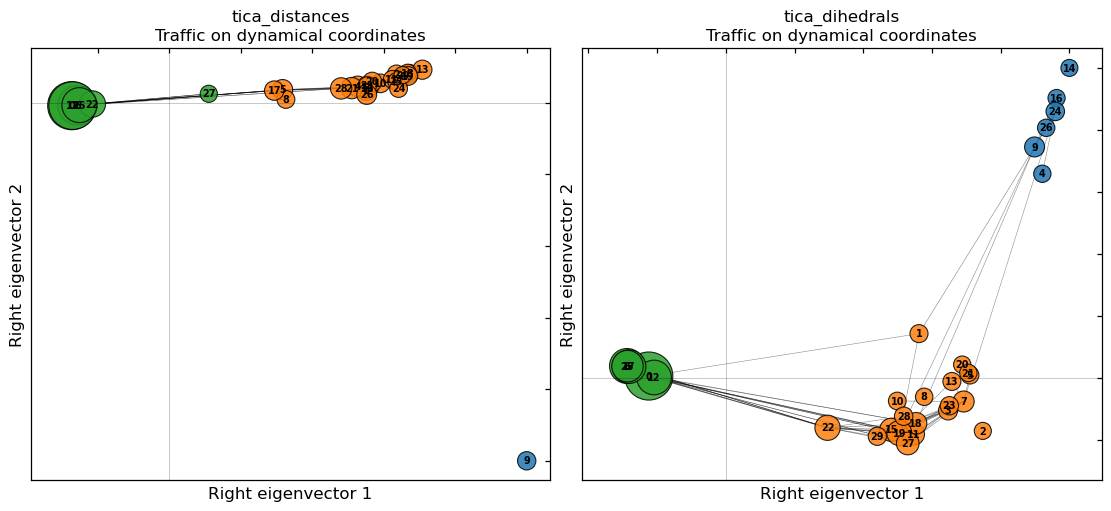

In [19]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(trajectories_labels),
    figsize=(5.5 * len(trajectories_labels), 5),
    constrained_layout=True
)

if len(trajectories_labels) == 1:
    axs = [axs]

dynamical_graph_dict = {}
dynamical_pos_dict = {}
dynamical_traffic_dict = {}
dynamical_eigvals_dict = {}
dynamical_eigvecs_dict = {}

for ax, name in zip(axs, trajectories_labels):
    msm = msm_dict[name]
    macro_assignments_micro = macro_assignments_micro_dict[name]

    ax, G_plot, pos, traffic, eigvals, eigvecs = plot_microstate_traffic_dynamical_layout(
        msm=msm,
        macro_assignments_micro=macro_assignments_micro,
        ax=ax,
        x_mode=1,
        y_mode=2,
        min_traffic_quantile=0.80,
        top_k_edges=None,
        node_size_range=(150, 1200),
        edge_width_range=(0.4, 5.0),
        show_labels=True,
        jitter=0.0
    )

    ax.set_title(
        f"{name}\n"
        f"Traffic on dynamical coordinates"
    )

    dynamical_graph_dict[name] = G_plot
    dynamical_pos_dict[name] = pos
    dynamical_traffic_dict[name] = traffic
    dynamical_eigvals_dict[name] = eigvals
    dynamical_eigvecs_dict[name] = eigvecs

plt.show()

In [20]:
def plot_first_dynamical_mode_network(
    msm,
    macro_assignments_micro=None,
    ax=None,
    labels=None,
    x_mode=1,
    y_quantity="population",
    min_traffic_quantile=0.80,
    top_k_edges=None,
    node_size_range=(100, 1200),
    edge_width_range=(0.4, 5.0),
    show_labels=True,
):
    """
    Plot traffic network using first nontrivial dynamical mode on x-axis.

    y_quantity:
        - "population": y_i = pi_i
        - "zero": y_i = 0, useful for a one-dimensional reaction coordinate
    """

    T = np.asarray(msm.transition_matrix, dtype=float)
    pi = np.asarray(msm.stationary_distribution, dtype=float)
    pi = pi / pi.sum()

    n = T.shape[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3))

    if labels is None:
        labels = {i: str(i) for i in range(n)}
    else:
        labels = {i: str(labels[i]) for i in range(n)}

    x, _, eigvals, eigvecs = get_dynamical_eigenvector_coordinates(
        msm=msm,
        x_mode=x_mode,
        y_mode=min(x_mode + 1, n - 1),
        normalize=True,
    )

    if y_quantity == "population":
        y = pi / pi.max()
    elif y_quantity == "zero":
        y = np.zeros(n)
    else:
        raise ValueError("y_quantity must be 'population' or 'zero'.")

    pos = {i: np.array([x[i], y[i]]) for i in range(n)}

    traffic = compute_equilibrium_traffic(T, pi)
    nonzero_traffic = traffic[traffic > 0]

    if min_traffic_quantile is not None:
        min_traffic = np.quantile(nonzero_traffic, min_traffic_quantile)
    else:
        min_traffic = 0.0

    edge_candidates = []

    for i in range(n):
        for j in range(i + 1, n):
            if traffic[i, j] >= min_traffic:
                edge_candidates.append((i, j, traffic[i, j]))

    edge_candidates = sorted(edge_candidates, key=lambda x: x[2], reverse=True)

    if top_k_edges is not None:
        edge_candidates = edge_candidates[:top_k_edges]

    G_plot = nx.Graph()
    G_plot.add_nodes_from(range(n))

    for i, j, weight in edge_candidates:
        G_plot.add_edge(i, j, weight=weight)

    edges = list(G_plot.edges())
    weights = np.array([G_plot[u][v]["weight"] for u, v in edges])

    smin, smax = node_size_range

    if pi.max() > pi.min():
        node_sizes = smin + (pi - pi.min()) / (pi.max() - pi.min()) * (smax - smin)
    else:
        node_sizes = np.full(n, 0.5 * (smin + smax))

    if macro_assignments_micro is not None:
        macro_assignments_micro = np.asarray(macro_assignments_micro)
        cmap = plt.get_cmap("tab10")
        node_colors = [
            cmap(int(macro_assignments_micro[i]) % 10)
            for i in range(n)
        ]
    else:
        node_colors = ["lightgrey"] * n

    if len(weights) > 0 and weights.max() > weights.min():
        wmin, wmax = edge_width_range
        edge_widths = wmin + (weights - weights.min()) / (weights.max() - weights.min()) * (wmax - wmin)
    elif len(weights) > 0:
        edge_widths = np.full(len(weights), np.mean(edge_width_range))
    else:
        edge_widths = []

    nx.draw_networkx_edges(
        G_plot,
        pos,
        ax=ax,
        edgelist=edges,
        width=edge_widths,
        alpha=0.45
    )

    nx.draw_networkx_nodes(
        G_plot,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors="black",
        linewidths=0.8,
        alpha=0.85
    )

    if show_labels:
        nx.draw_networkx_labels(
            G_plot,
            pos,
            labels=labels,
            ax=ax,
            font_size=7,
            font_weight="bold"
        )

    ax.set_xlabel(f"Right eigenvector {x_mode}")
    ax.set_ylabel(y_quantity)

    ax.set_title(
        f"Traffic along first slow mode\n"
        f"$\\lambda_{x_mode}$ = {eigvals[x_mode]:.3f}"
    )

    ax.axvline(0, color="black", linewidth=0.5, alpha=0.3)

    if y_quantity == "zero":
        ax.set_yticks([])

    return ax, G_plot, pos, traffic, eigvals, eigvecs

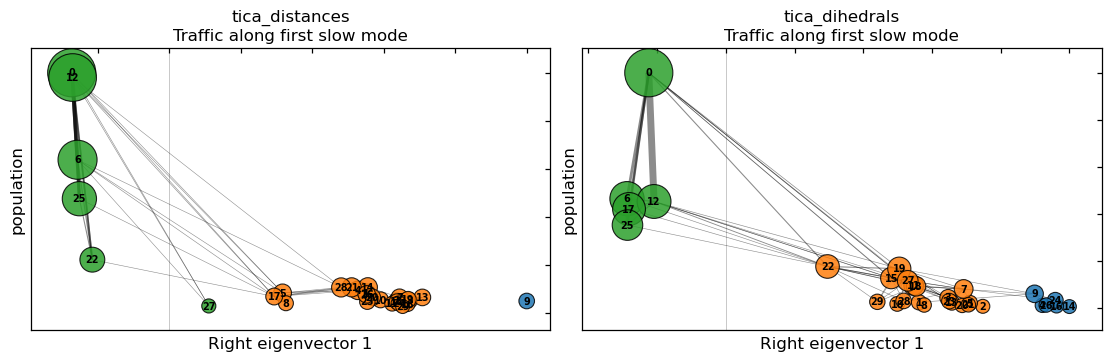

In [21]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(trajectories_labels),
    figsize=(5.5 * len(trajectories_labels), 3.5),
    constrained_layout=True
)

if len(trajectories_labels) == 1:
    axs = [axs]

for ax, name in zip(axs, trajectories_labels):
    plot_first_dynamical_mode_network(
        msm=msm_dict[name],
        macro_assignments_micro=macro_assignments_micro_dict[name],
        ax=ax,
        x_mode=1,
        y_quantity="population",
        min_traffic_quantile=0.80,
        top_k_edges=None,
        show_labels=True
    )

    ax.set_title(f"{name}\nTraffic along first slow mode")

plt.show()

# cored traj

In [22]:


def core_discrete_trajectory(hard, min_core_frames):
    """
    Core a discrete trajectory with any number of states.

    A transition to a new state is accepted only if the new state persists
    for at least min_core_frames consecutive frames.

    Parameters
    ----------
    hard : array-like, shape (n_frames,)
        Discrete state trajectory. Values can be 0, 1, 2, ...
    min_core_frames : int
        Minimum number of consecutive frames required to accept entry
        into a new state.

    Returns
    -------
    cored : ndarray, shape (n_frames,)
        Cored trajectory with the same state labels as hard.
    """

    hard = np.asarray(hard, dtype=int)

    if hard.ndim != 1:
        raise ValueError("hard must be a one-dimensional discrete trajectory.")

    if len(hard) == 0:
        return hard.copy()

    if min_core_frames < 1:
        raise ValueError("min_core_frames must be >= 1.")

    cored = np.empty_like(hard)

    current = hard[0]
    cored[0] = current

    i = 1

    while i < len(hard):
        candidate = hard[i]

        # Still in the current accepted state
        if candidate == current:
            cored[i] = current
            i += 1
            continue

        # Candidate differs from current.
        # Check whether this candidate persists for min_core_frames.
        end = i + min_core_frames

        if end <= len(hard) and np.all(hard[i:end] == candidate):
            # Accept transition into candidate state.
            current = candidate
            cored[i:end] = current
            i = end
        else:
            # Reject as short excursion.
            cored[i] = current
            i += 1

    return cored

In [23]:
min_core_markov_steps = 1
min_core_mus = min_core_markov_steps * MSM_LAG_NS / 1000  # convert to microseconds
print("Minimum core time (microseconds):", min_core_mus)
min_core_frames = int(min_core_mus / time_step_micros)

cored_assignments_timeseries_dict = {}

for name in trajectories_labels:
    hard = hard_assignments_timeseries_dict[name]

    cored = core_discrete_trajectory(
        hard,
        min_core_frames=min_core_frames
    )

    cored_assignments_timeseries_dict[name] = cored

Minimum core time (microseconds): 0.2


Distances

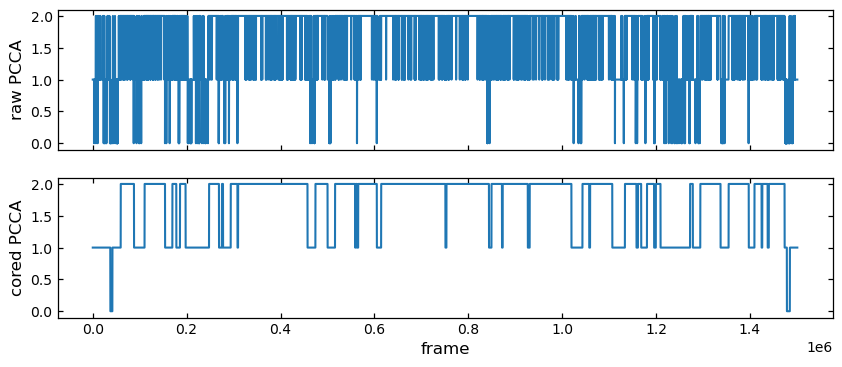

In [24]:
name = trajectories_labels[0]

tmin_mus = 0
tmax_mus = 300

frame_min = int(tmin_mus / time_step_micros)
frame_max = int(tmax_mus / time_step_micros)

x = np.arange(frame_min, frame_max)

fig, axs = plt.subplots(nrows=2, figsize=(10, 4), sharex=True)

axs[0].plot(x, hard_assignments_timeseries_dict[name][frame_min:frame_max])
axs[0].set_ylabel("raw PCCA")

axs[1].plot(x, cored_assignments_timeseries_dict[name][frame_min:frame_max])
axs[1].set_ylabel("cored PCCA")
axs[1].set_xlabel("frame")

plt.show()

Dihedrals

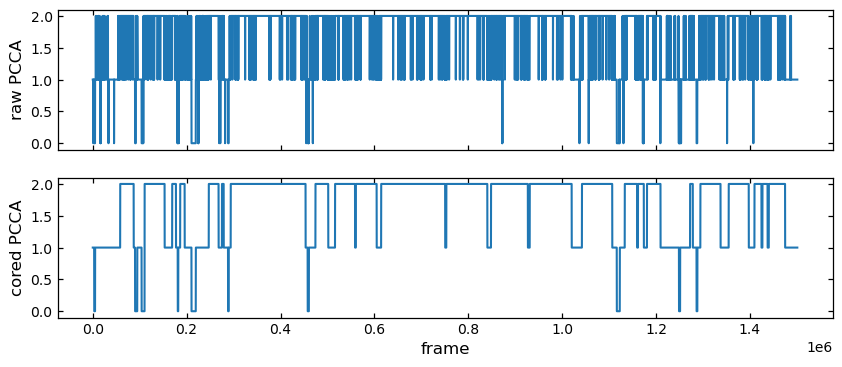

In [25]:
name = trajectories_labels[1]

tmin_mus = 0
tmax_mus = 300

frame_min = int(tmin_mus / time_step_micros)
frame_max = int(tmax_mus / time_step_micros)

x = np.arange(frame_min, frame_max)

fig, axs = plt.subplots(nrows=2, figsize=(10, 4), sharex=True)

axs[0].plot(x, hard_assignments_timeseries_dict[name][frame_min:frame_max])
axs[0].set_ylabel("raw PCCA")

axs[1].plot(x, cored_assignments_timeseries_dict[name][frame_min:frame_max])
axs[1].set_ylabel("cored PCCA")
axs[1].set_xlabel("frame")

plt.show()